# 07 — เปรียบเทียบผลเลือกตั้ง ปี 66 vs ปี 69
## ลำปาง เขต 2

วิเคราะห์ว่าพรรค/ผู้สมัครคนไหนขึ้น-ลง และเทรนด์เปลี่ยนไปอย่างไร

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams['font.family'] = 'Tahoma'
mpl.rcParams['font.size'] = 12

# ลองใช้ TH Sarabun New ถ้ามี
try:
    mpl.font_manager.fontManager.addfont('../thsarabunnew-webfont.ttf')
    mpl.rcParams['font.family'] = 'TH Sarabun New'
    mpl.rcParams['font.size'] = 16
except:
    pass

## 1. โหลดข้อมูล

In [2]:
# ปี 66
cand_66 = pd.read_csv('../cleaned/election66_candidate.csv')
pl_66 = pd.read_csv('../cleaned/election66_partylist.csv')

# ปี 69
results_69 = pd.read_csv('../cleaned/master_results_cleaned.csv')
summary_69 = pd.read_csv('../cleaned/master_summary_cleaned.csv')

# Aggregate ปี 69 ส.ส.เขต
cand_69 = results_69[results_69['type'] == 'เขต'].groupby('name')['score'].sum().reset_index()
cand_69.columns = ['candidate_name', 'score']
cand_69 = cand_69.sort_values('score', ascending=False).reset_index(drop=True)
cand_69['score_pct'] = cand_69['score'] / cand_69['score'].sum() * 100

# Aggregate ปี 69 บัญชีรายชื่อ
pl_69 = results_69[results_69['type'] == 'บช'].groupby('name')['score'].sum().reset_index()
pl_69.columns = ['party', 'score']
pl_69 = pl_69.sort_values('score', ascending=False).reset_index(drop=True)
pl_69['score_pct'] = pl_69['score'] / pl_69['score'].sum() * 100

print(f'ปี 66: {len(cand_66)} ผู้สมัครเขต, {len(pl_66)} พรรค')
print(f'ปี 69: {len(cand_69)} ผู้สมัครเขต, {len(pl_69)} พรรค')

ปี 66: 11 ผู้สมัครเขต, 67 พรรค
ปี 69: 69 ผู้สมัครเขต, 67 พรรค


## 2. เปรียบเทียบ ส.ส.เขต — Top ผู้สมัคร

In [3]:
# Mapping ผู้สมัครที่ลงทั้ง 2 สมัย (ชื่ออาจสะกดต่างกันเล็กน้อย)
# ปี 66: ธนาธร โล่ห์สุนทร (เพื่อไทย), กฤตภพ (ก้าวไกล), จินดา (พลังประชารัฐ)
# ปี 69: ดาซัย/ดาชัย (กล้าธรรม?), สุวิภา (ประชาชน), ธนาธร (เพื่อไทย)

top66 = cand_66[['candidate_name','party','score','score_pct']].head(6).copy()
top66['year'] = '2566'

top69 = cand_69[['candidate_name','score','score_pct']].head(6).copy()
top69['year'] = '2569'

print('=== ปี 66 Top 6 ส.ส.เขต ===')
for _, r in top66.iterrows():
    print(f"  {r['candidate_name']:<35s} {r['party']:<20s} {r['score']:>6,.0f} ({r['score_pct']:.1f}%)")

print()
print('=== ปี 69 Top 6 ส.ส.เขต ===')
for _, r in top69.iterrows():
    print(f"  {r['candidate_name']:<35s} {r['score']:>6,.0f} ({r['score_pct']:.1f}%)")

=== ปี 66 Top 6 ส.ส.เขต ===
  นายธนาธร โล่ห์สุนทร                 เพื่อไทย             41,114 (34.4%)
  นายกฤตภพ สติดีนิติวงศ์              ก้าวไกล              35,484 (29.7%)
  นายจินดา วงศ์สวัสดิ์                พลังประชารัฐ         16,919 (14.1%)
  นายภาวัฒน์ พยัคฆบุตร                ไทยสร้างไทย           8,151 (6.8%)
  นายดลนรุตม์ ชาญเศรษฐนนท์            รวมไทยสร้างชาติ       3,591 (3.0%)
  นางสาวกัญญารัตน์ วงศ์วรกุลกิจ       ประชาธิปัตย์          1,037 (0.9%)

=== ปี 69 Top 6 ส.ส.เขต ===
  นายดาซัย เอกปฐพี                    32,531 (36.4%)
  นางสาวสุวิภา กุศลจูง                24,565 (27.5%)
  นายธนาธร โล่ห์สุนทร                 16,481 (18.5%)
  นางสาววิชุดา ว่องวัฒนวิโรจน์         3,721 (4.2%)
  นายศรีพรหม หอมยก                     2,249 (2.5%)
  พันเอกสันทัด ภัทรกิตตินนท์           2,238 (2.5%)


In [4]:
# ผู้สมัครที่ลงทั้ง 2 สมัย — ธนาธร โล่ห์สุนทร
returning = {
    'นายธนาธร โล่ห์สุนทร': {'party': 'เพื่อไทย'},
}

# หาชื่อที่ตรงกัน
for name, info in returning.items():
    s66 = cand_66[cand_66['candidate_name'] == name]
    s69 = cand_69[cand_69['candidate_name'].str.contains('ธนาธร')]
    if len(s66) > 0 and len(s69) > 0:
        v66 = s66.iloc[0]['score']
        v69 = s69.iloc[0]['score']
        p66 = s66.iloc[0]['score_pct']
        p69 = s69.iloc[0]['score_pct']
        print(f"{name} ({info['party']})")
        print(f"  ปี 66: {v66:>6,.0f} ({p66:.1f}%)")
        print(f"  ปี 69: {v69:>6,.0f} ({p69:.1f}%)")
        print(f"  เปลี่ยนแปลง: {v69-v66:>+6,.0f} คะแนน ({p69-p66:>+.1f}%)")

นายธนาธร โล่ห์สุนทร (เพื่อไทย)
  ปี 66: 41,114 (34.4%)
  ปี 69: 16,481 (18.5%)
  เปลี่ยนแปลง: -24,633 คะแนน (-15.9%)


## 3. เปรียบเทียบบัญชีรายชื่อ — พรรคหลัก

In [5]:
# Mapping พรรคระหว่าง 2 สมัย
# ก้าวไกล (66) -> ประชาชน (69)
# เพื่อไทย -> เพื่อไทย
# พลังประชารัฐ (66) -> กล้าธรรม (69)?

party_mapping = {
    'เพื่อไทย': 'เพื่อไทย',
    'ก้าวไกล': 'ประชาชน',
    'รวมไทยสร้างชาติ': 'รวมไทยสร้างชาติ',
    'ภูมิใจไทย': 'ภูมิใจไทย',
    'ประชาธิปัตย์': 'ประชาธิปัตย์',
}

comparison = []
for p66, p69 in party_mapping.items():
    s66 = pl_66[pl_66['party'] == p66]
    s69 = pl_69[pl_69['party'] == p69]
    if len(s66) > 0 and len(s69) > 0:
        v66 = s66.iloc[0]['score']
        v69 = s69.iloc[0]['score']
        pct66 = s66.iloc[0]['score_pct']
        pct69 = s69.iloc[0]['score_pct']
        comparison.append({
            'party_66': p66, 'party_69': p69,
            'score_66': v66, 'score_69': v69,
            'pct_66': pct66, 'pct_69': pct69,
            'score_change': v69 - v66,
            'pct_change': pct69 - pct66,
        })

comp_df = pd.DataFrame(comparison)
comp_df

,party_66,party_69,score_66,score_69,pct_66,pct_69,score_change,pct_change
0,เพื่อไทย,เพื่อไทย,44633,21375,37.31887,21.298750,-23258,-16.020120
1,ก้าวไกล,ประชาชน,42689,29250,35.69344,29.145659,-13439,-6.547781
2,รวมไทยสร้างชาติ,รวมไทยสร้างชาติ,6352,5598,5.31108,5.578031,-754,0.266951
3,ภูมิใจไทย,ภูมิใจไทย,2378,6047,1.98831,6.025429,3669,4.037119
4,ประชาธิปัตย์,ประชาธิปัตย์,922,3784,0.77091,3.770502,2862,2.999592


/var/folders/kd/fgxw73j51n56v52rqjz_9xkw0000gn/T/ipykernel_30769/1592062686.py:33: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Tahoma.
  plt.tight_layout()
/Users/dewwts/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


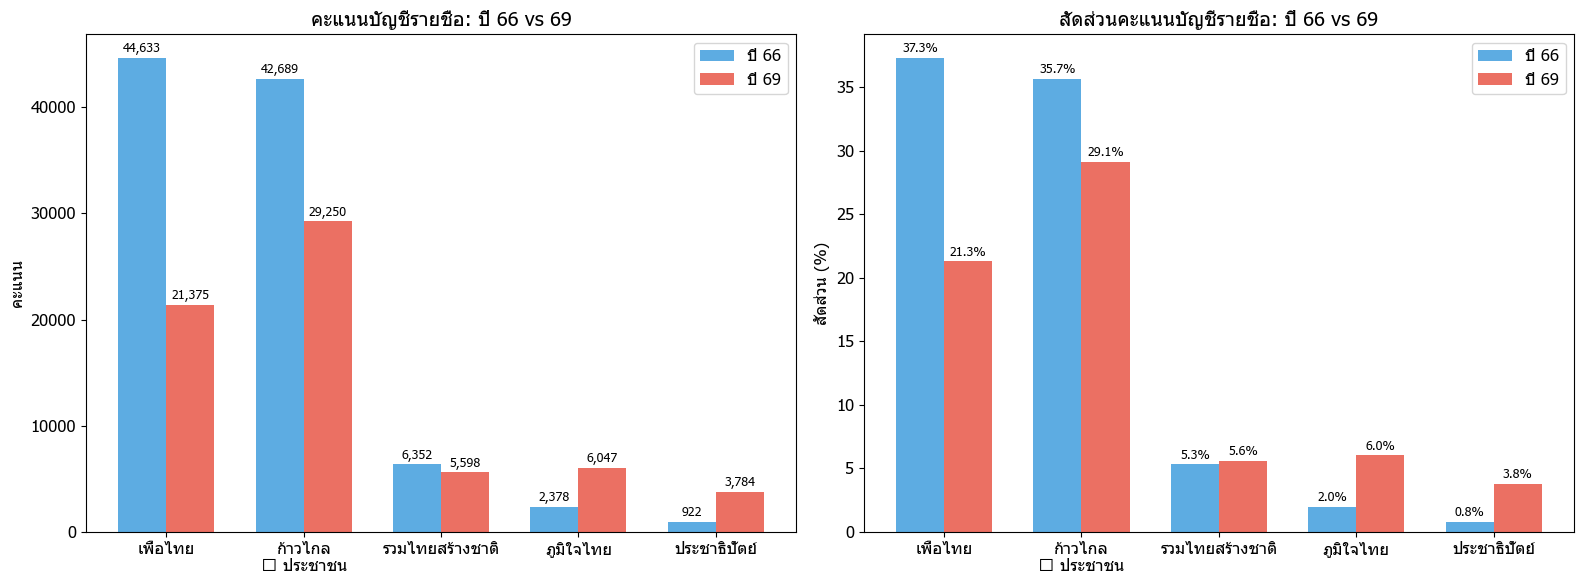

In [6]:
# กราฟเปรียบเทียบคะแนนบัญชีรายชื่อ ปี 66 vs 69
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = [f"{r['party_66']}\n→ {r['party_69']}" if r['party_66'] != r['party_69'] else r['party_66'] 
          for _, r in comp_df.iterrows()]
x = np.arange(len(labels))
width = 0.35

# คะแนนดิบ
ax = axes[0]
bars1 = ax.bar(x - width/2, comp_df['score_66'], width, label='ปี 66', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, comp_df['score_69'], width, label='ปี 69', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel('คะแนน')
ax.set_title('คะแนนบัญชีรายชื่อ: ปี 66 vs 69')
ax.legend()
ax.bar_label(bars1, fmt='{:,.0f}', fontsize=9, padding=2)
ax.bar_label(bars2, fmt='{:,.0f}', fontsize=9, padding=2)

# สัดส่วน %
ax = axes[1]
bars1 = ax.bar(x - width/2, comp_df['pct_66'], width, label='ปี 66', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, comp_df['pct_69'], width, label='ปี 69', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel('สัดส่วน (%)')
ax.set_title('สัดส่วนคะแนนบัญชีรายชื่อ: ปี 66 vs 69')
ax.legend()
ax.bar_label(bars1, fmt='{:.1f}%', fontsize=9, padding=2)
ax.bar_label(bars2, fmt='{:.1f}%', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

## 4. Swing Analysis — พรรคไหนขึ้น/ลง

/var/folders/kd/fgxw73j51n56v52rqjz_9xkw0000gn/T/ipykernel_30769/3938035380.py:14: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Tahoma.
  plt.tight_layout()


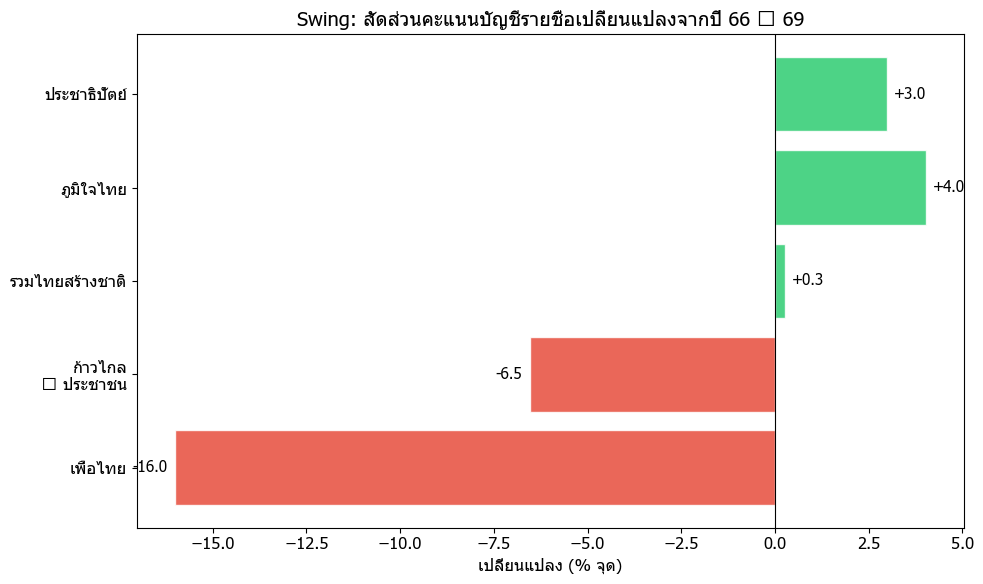

In [7]:
# Swing chart (เปลี่ยนแปลง %)
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in comp_df['pct_change']]
labels = [f"{r['party_66']}\n→ {r['party_69']}" if r['party_66'] != r['party_69'] else r['party_66'] 
          for _, r in comp_df.iterrows()]

bars = ax.barh(labels, comp_df['pct_change'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('เปลี่ยนแปลง (% จุด)')
ax.set_title('Swing: สัดส่วนคะแนนบัญชีรายชื่อเปลี่ยนแปลงจากปี 66 → 69')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%+.1f', fontsize=11, padding=5)

plt.tight_layout()
plt.show()

## 5. สถิติบัตร: ปี 66 vs 69

In [8]:
# ปี 66 (จากข้อมูล กกต.)
stat_66 = {
    'ผู้มีสิทธิ์': 153674,
    'มาใช้สิทธิ์': 119599,
    'turnout_pct': 77.83,
}

# ปี 69
summary_69_khet = summary_69[summary_69['type'] == 'เขต']
total_ballots_69 = summary_69_khet['total_ballots'].sum()
valid_69 = summary_69_khet['valid_ballots'].sum()
invalid_69 = summary_69_khet['invalid_ballots'].sum()
novote_69 = summary_69_khet['no_vote_ballots'].sum()

ballot_compare = pd.DataFrame({
    'รายการ': ['ผู้มาใช้สิทธิ์', 'บัตรดี', 'บัตรเสีย (%)', 'บัตรไม่ประสงค์ลงคะแนน (%)'],
    'ปี 66': [
        f"{stat_66['มาใช้สิทธิ์']:,} ({stat_66['turnout_pct']:.1f}%)",
        f"109,622 (91.7%)",
        f"7,339 (6.1%)",
        f"2,638 (2.2%)",
    ],
    'ปี 69': [
        f"{total_ballots_69:,.0f}",
        f"{valid_69:,.0f} ({valid_69/total_ballots_69*100:.1f}%)",
        f"{invalid_69:,.0f} ({invalid_69/total_ballots_69*100:.1f}%)",
        f"{novote_69:,.0f} ({novote_69/total_ballots_69*100:.1f}%)",
    ],
})

ballot_compare.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]}]
)

,รายการ,ปี 66,ปี 69
0,ผู้มาใช้สิทธิ์,"119,599 (77.8%)","152,934"
1,บัตรดี,"109,622 (91.7%)","98,015 (64.1%)"
2,บัตรเสีย (%),"7,339 (6.1%)","7,810 (5.1%)"
3,บัตรไม่ประสงค์ลงคะแนน (%),"2,638 (2.2%)","5,425 (3.5%)"


## 6. ภาพรวมการเปลี่ยนแปลง ปี 66 → 69

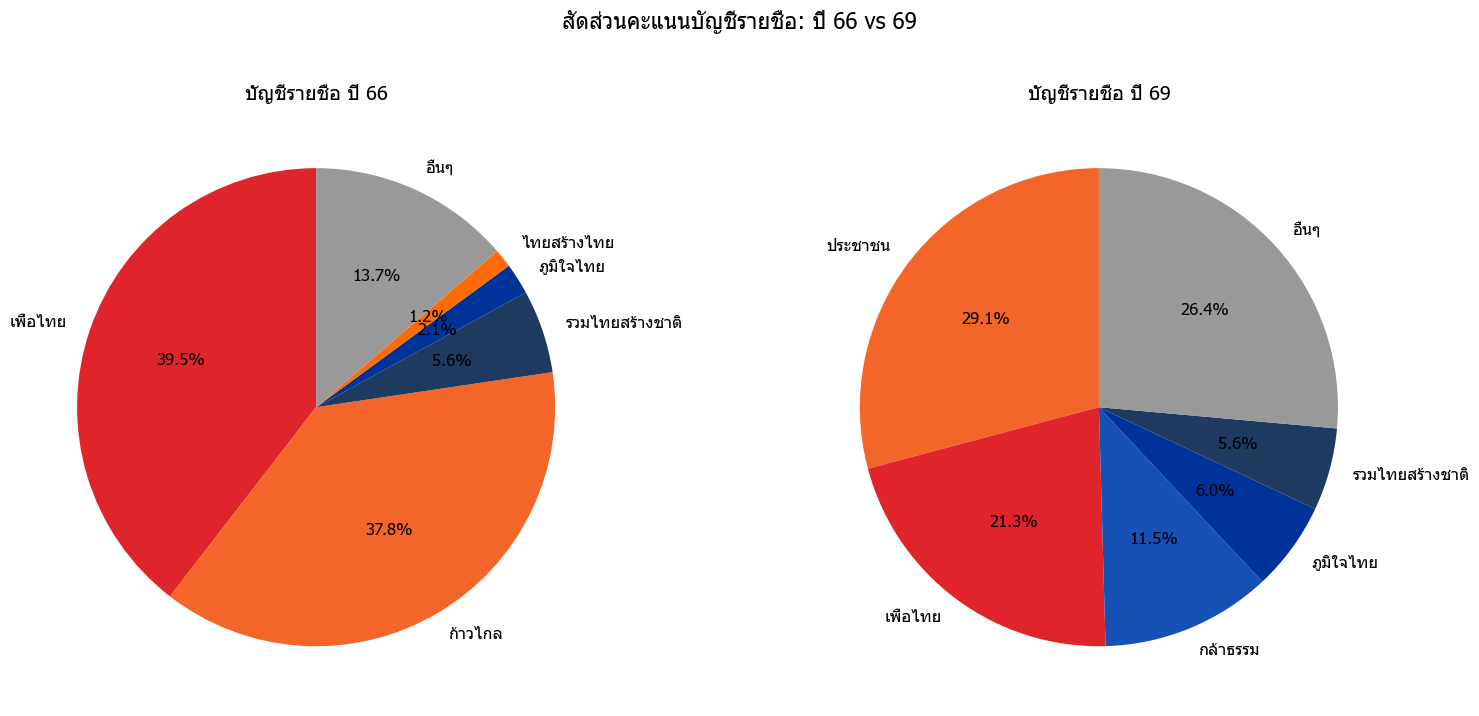

In [9]:
# Pie chart เปรียบเทียบ
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# สีพรรค
party_colors = {
    'เพื่อไทย': '#E0242B',
    'ก้าวไกล': '#F4652A',
    'ประชาชน': '#F4652A',
    'พลังประชารัฐ': '#1651B5',
    'กล้าธรรม': '#1651B5',
    'รวมไทยสร้างชาติ': '#1E3A5F',
    'ภูมิใจไทย': '#003399',
    'ประชาธิปัตย์': '#0055AA',
    'ไทยสร้างไทย': '#FF6B00',
}

# ปี 66 - top 5 + อื่นๆ
top5_66 = pl_66.head(5).copy()
other_66 = pd.DataFrame({'party': ['อื่นๆ'], 'score': [pl_66.iloc[5:]['score'].sum()], 'score_pct': [pl_66.iloc[5:]['score_pct'].sum()]})
pie_66 = pd.concat([top5_66, other_66])
colors_66 = [party_colors.get(p, '#999999') for p in pie_66['party']]

axes[0].pie(pie_66['score'], labels=pie_66['party'], autopct='%1.1f%%', colors=colors_66, startangle=90)
axes[0].set_title('บัญชีรายชื่อ ปี 66')

# ปี 69 - top 5 + อื่นๆ
top5_69 = pl_69.head(5).copy()
other_69 = pd.DataFrame({'party': ['อื่นๆ'], 'score': [pl_69.iloc[5:]['score'].sum()], 'score_pct': [pl_69.iloc[5:]['score_pct'].sum()]})
pie_69 = pd.concat([top5_69, other_69])
colors_69 = [party_colors.get(p, '#999999') for p in pie_69['party']]

axes[1].pie(pie_69['score'], labels=pie_69['party'], autopct='%1.1f%%', colors=colors_69, startangle=90)
axes[1].set_title('บัญชีรายชื่อ ปี 69')

plt.suptitle('สัดส่วนคะแนนบัญชีรายชื่อ: ปี 66 vs 69', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. สรุปผล

### ข้อค้นพบหลัก

**หมายเหตุ:** ข้อมูลปี 66 เป็นระดับเขตรวม (ไม่มีรายหน่วย/ตำบล)  
ข้อมูลปี 69 มีรายหน่วยเลือกตั้ง ถ้าได้ข้อมูลปี 66 รายหน่วยมาเพิ่ม จะวิเคราะห์ swing รายตำบลได้ลึกกว่านี้